In [ ]:
!mkdir data/
!wget https://raw.githubusercontent.com/Abhijeet-2003/Air_Quality/main/city_day.csv


mkdir: cannot create directory ‘data/’: File exists
--2024-04-25 17:09:26--  https://raw.githubusercontent.com/Abhijeet-2003/Air_Quality/main/city_day.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2574056 (2.5M) [text/plain]
Saving to: ‘city_day.csv.5’

city_day.csv.5      100%[===================>]   2.45M  --.-KB/s    in 0.01s   

2024-04-25 17:09:26 (195 MB/s) - ‘city_day.csv.5’ saved [2574056/2574056]



In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets, neighbors, linear_model
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.svm import SVC
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split

import os

if not os.path.exists('figures'):
    os.makedirs('figures')

In [ ]:
abhijeet_df = pd.read_csv('/content/city_day.csv')

df = abhijeet_df.copy()

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [ ]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [ ]:
df.dtypes

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

In [ ]:

unique_values = df['AQI_Bucket'].unique()
print(unique_values)


[nan 'Poor' 'Very Poor' 'Severe' 'Moderate' 'Satisfactory' 'Good']


In [ ]:
dff = df.drop(['City', 'Date', 'AQI'], axis = 1)
dff.rename(columns = {'AQI_Bucket':'Air_quality'}, inplace = True)


In [ ]:
dff = dff.dropna(subset=['Air_quality'])

In [ ]:
for column in dff.columns:
  if dff[column].isnull().any() :
    dff[column].fillna(np.mean(dff[column]), inplace=True)


In [ ]:
dff.isnull().sum()

PM2.5          0
PM10           0
NO             0
NO2            0
NOx            0
NH3            0
CO             0
SO2            0
O3             0
Benzene        0
Toluene        0
Xylene         0
Air_quality    0
dtype: int64

In [ ]:
mapping = {
    "Good": 1,
    "Satisfactory": 2,
    "Moderate": 3,
    "Poor": 4,
    "Very Poor": 5,
    "Severe": 6
}

dff['Air_quality'] = dff['Air_quality'].map(mapping)

In [ ]:
unique_values = dff['Air_quality'].unique()
print(unique_values)


[4 5 6 3 2 1]


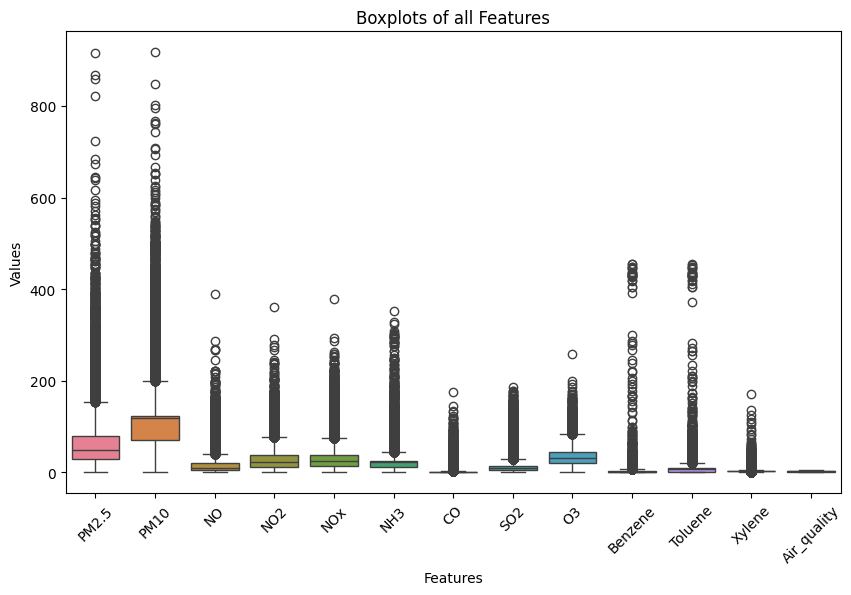

In [ ]:
numeric_columns = dff.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
sns.boxplot(data=dff[numeric_columns])

plt.title('Boxplots of all Features')
plt.xlabel('Features')
plt.ylabel('Values')


plt.xticks(rotation=45)

plt.savefig('figures/box_plot_before_outlier_removal.png')  # Save the figure
plt.show()


In [ ]:

for column in dff.columns:
  if column != 'Air_quality':
    q1 = dff[column].quantile(0.25)
    q3 = dff[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    dff = dff[(dff[column] >= lower_bound) & (dff[column] <= upper_bound)]


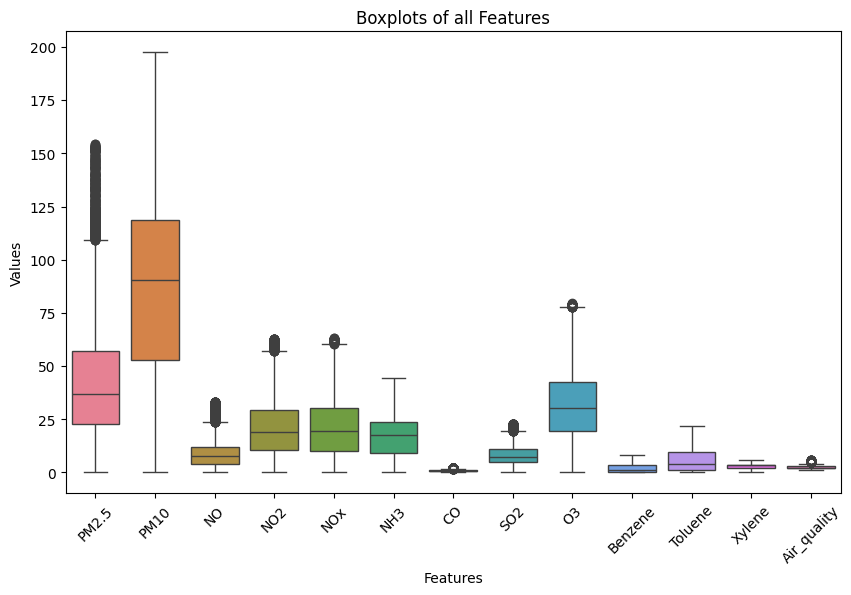

In [ ]:
numeric_columns = dff.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
sns.boxplot(data=dff[numeric_columns])

plt.title('Boxplots of all Features')
plt.xlabel('Features')
plt.ylabel('Values')


plt.xticks(rotation=45)
plt.savefig('figures/box_plot_after_outlier_removal.png')  # Save the figure
plt.show()


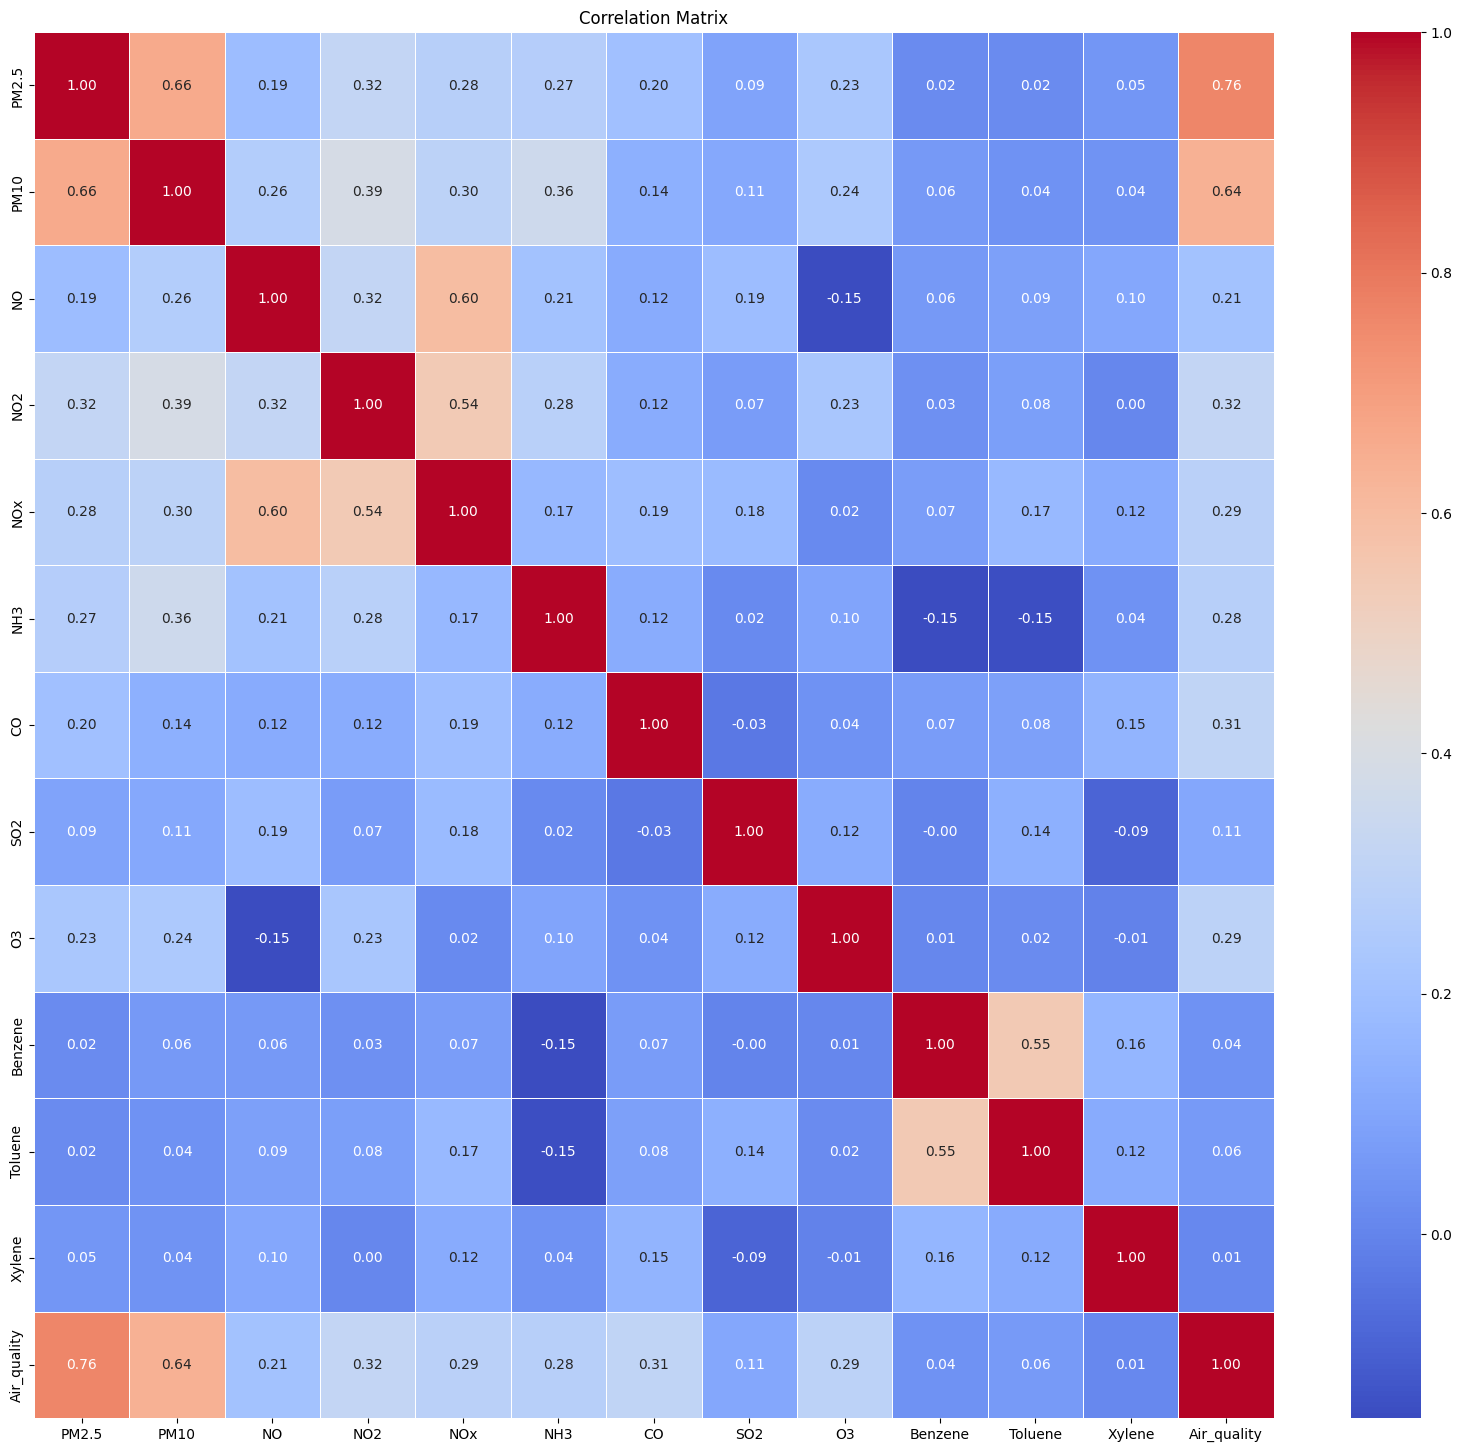

In [ ]:
corr_matrix = dff.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')

plt.savefig('figures/corr.png')  # Save the figure
plt.show()

In [ ]:
X = dff.copy()
X.drop('Air_quality', axis=1, inplace=True)

y = dff['Air_quality']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
}

model_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    model_scores[name] = model.score(X_test, y_test)

print("Scores before hyperparameter tuning:")
for name, score in model_scores.items():
    print(f"{name}: {score:.4f}")

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Scores before hyperparameter tuning:
Logistic Regression: 0.6404
Decision Tree: 0.7352
KNN: 0.7852
Random Forest: 0.8190
Naive Bayes: 0.6062


In [ ]:
from sklearn.model_selection import GridSearchCV

best_models = {}

for name, model in models.items():

    if name == "Logistic Regression":
        hyperparameters = {'C': [0.1, 1, 10], 'solver': ['liblinear']}
    elif name == "Decision Tree":
        hyperparameters = {'max_depth': [5, 10, 20]}
    elif name == "KNN":
        hyperparameters = {'n_neighbors': [3, 5, 7]}
    elif name == "Random Forest":
        hyperparameters = {'n_estimators': [10, 50, 100], 'max_depth': [5, 10, 20]}
    elif name == "Naive Bayes":
        hyperparameters = {'var_smoothing': np.logspace(0, 9, num=10, base=2)}

    print('Tuning ', name, '...')

    grid_search = GridSearchCV(model, hyperparameters, cv=5)
    grid_search.fit(X_train, y_train)


    best_models[name] = grid_search.best_estimator_



Tuning  Logistic Regression ...
Tuning  Decision Tree ...
Tuning  KNN ...
Tuning  Random Forest ...
Tuning  Naive Bayes ...


In [ ]:
best_models

{'Logistic Regression': LogisticRegression(C=1, solver='liblinear'),
 'Decision Tree': DecisionTreeClassifier(max_depth=10),
 'KNN': KNeighborsClassifier(n_neighbors=7),
 'Random Forest': RandomForestClassifier(max_depth=20),
 'Naive Bayes': GaussianNB(var_smoothing=1.0)}

In [ ]:
best_model_scores = {}

for name, model in best_models.items():
    best_model_scores[name] = model.score(X_test, y_test)

print("Scores after hyperparameter tuning:")
for name, score in best_model_scores.items():
    print(f"{name}: {score:.4f}")


Scores after hyperparameter tuning:
Logistic Regression: 0.7278
Decision Tree: 0.7805
KNN: 0.7887
Random Forest: 0.8171
Naive Bayes: 0.6896


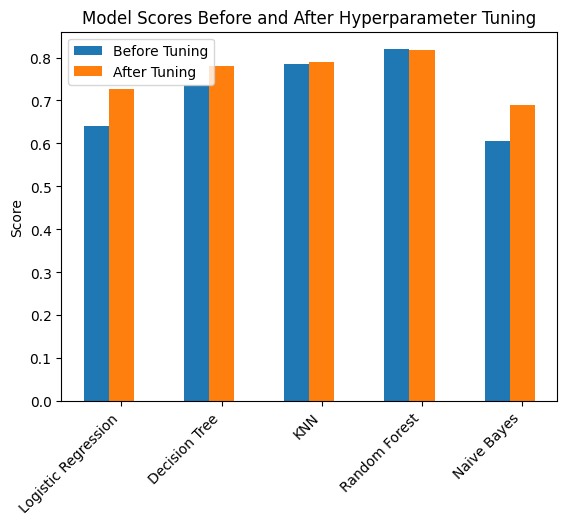

In [ ]:

model_names = list(model_scores.keys())
scores_before = list(model_scores.values())
scores_after = list(best_model_scores.values())

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots()

rects1 = ax.bar(x - width, scores_before, width, label='Before Tuning')
rects2 = ax.bar(x, scores_after, width, label='After Tuning')

ax.set_ylabel('Score')
ax.set_title('Model Scores Before and After Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')

ax.legend()
plt.savefig('figures/scores_normal.png')  # Save the figure
plt.show()


In [ ]:
num_components = 4
pca = PCA(n_components=num_components)
X_test_pca = pca.fit_transform(X_test)
X_train_pca = pca.fit_transform(X_train)

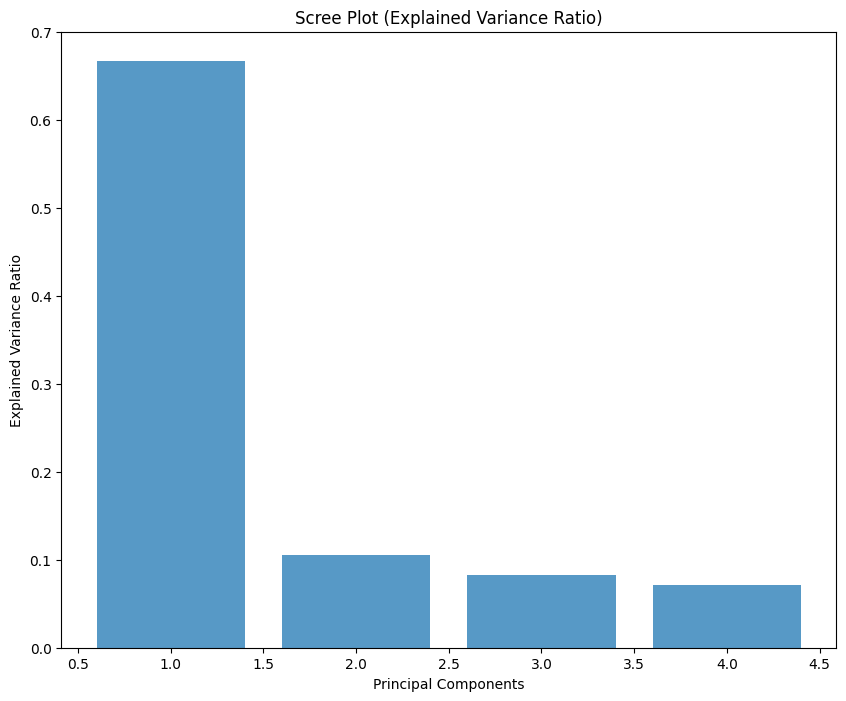

In [ ]:
plt.figure(figsize=(10, 8))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),pca.explained_variance_ratio_ , alpha=0.75, align='center')
plt.title('Scree Plot (Explained Variance Ratio)')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')

plt.savefig('figures/scree_plot_pca.png')  # Save the figure
plt.show()

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
}

model_scores = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    model_scores[name] = model.score(X_test_pca, y_test)

print("Scores before hyperparameter tuning:")
for name, score in model_scores.items():
    print(f"{name}: {score:.4f}")

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Scores before hyperparameter tuning:
Logistic Regression: 0.7183
Decision Tree: 0.6452
KNN: 0.7069
Random Forest: 0.7246
Naive Bayes: 0.6798


In [ ]:
from sklearn.model_selection import GridSearchCV

best_models = {}

for name, model in models.items():

    if name == "Logistic Regression":
        hyperparameters = {'C': [0.1, 1, 10], 'solver': ['liblinear']}
    elif name == "Decision Tree":
        hyperparameters = {'max_depth': [5, 10, 20]}
    elif name == "KNN":
        hyperparameters = {'n_neighbors': [3, 5, 7]}
    elif name == "Random Forest":
        hyperparameters = {'n_estimators': [10, 50, 100], 'max_depth': [5, 10, 20]}
    elif name == "Naive Bayes":
        hyperparameters = {'var_smoothing': np.logspace(0, 9, num=10, base=2)}

    print('Tuning ', name, '...')

    grid_search = GridSearchCV(model, hyperparameters, cv=5)
    grid_search.fit(X_train_pca, y_train)


    best_models[name] = grid_search.best_estimator_



Tuning  Logistic Regression ...
Tuning  Decision Tree ...
Tuning  KNN ...
Tuning  Random Forest ...
Tuning  Naive Bayes ...


In [ ]:
best_models

{'Logistic Regression': LogisticRegression(C=10, solver='liblinear'),
 'Decision Tree': DecisionTreeClassifier(max_depth=5),
 'KNN': KNeighborsClassifier(n_neighbors=7),
 'Random Forest': RandomForestClassifier(max_depth=10),
 'Naive Bayes': GaussianNB(var_smoothing=1.0)}

In [ ]:
best_model_scores = {}

for name, model in best_models.items():
    best_model_scores[name] = model.score(X_test_pca, y_test)

print("Scores after hyperparameter tuning:")
for name, score in best_model_scores.items():
    print(f"{name}: {score:.4f}")


Scores after hyperparameter tuning:
Logistic Regression: 0.6719
Decision Tree: 0.7187
KNN: 0.7124
Random Forest: 0.7266
Naive Bayes: 0.6656


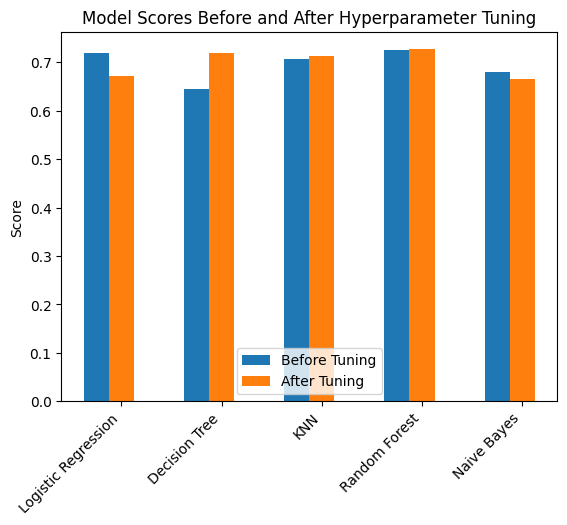

In [ ]:

model_names = list(model_scores.keys())
scores_before = list(model_scores.values())
scores_after = list(best_model_scores.values())

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots()

rects1 = ax.bar(x - width, scores_before, width, label='Before Tuning')
rects2 = ax.bar(x, scores_after, width, label='After Tuning')

ax.set_ylabel('Score')
ax.set_title('Model Scores Before and After Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')

ax.legend()

plt.savefig('figures/scores_pca.png')  # Save the figure
plt.show()


In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=4)

X_test_svd = svd.fit_transform(X_test)
X_train_svd = svd.fit_transform(X_train)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
}

model_scores = {}

for name, model in models.items():
    model.fit(X_train_svd, y_train)
    model_scores[name] = model.score(X_test_svd, y_test)

print("Scores before hyperparameter tuning:")
for name, score in model_scores.items():
    print(f"{name}: {score:.4f}")

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Scores before hyperparameter tuning:
Logistic Regression: 0.7069
Decision Tree: 0.6660
KNN: 0.7400
Random Forest: 0.7486
Naive Bayes: 0.7120


In [ ]:
from sklearn.model_selection import GridSearchCV

best_models = {}

for name, model in models.items():

    if name == "Logistic Regression":
        hyperparameters = {'C': [0.1, 1, 10], 'solver': ['liblinear']}
    elif name == "Decision Tree":
        hyperparameters = {'max_depth': [5, 10, 20]}
    elif name == "KNN":
        hyperparameters = {'n_neighbors': [3, 5, 7]}
    elif name == "Random Forest":
        hyperparameters = {'n_estimators': [10, 50, 100], 'max_depth': [5, 10, 20]}
    elif name == "Naive Bayes":
        hyperparameters = {'var_smoothing': np.logspace(0, 9, num=10, base=2)}

    print('Tuning ', name, '...')

    grid_search = GridSearchCV(model, hyperparameters, cv=5)
    grid_search.fit(X_train_svd, y_train)


    best_models[name] = grid_search.best_estimator_



Tuning  Logistic Regression ...
Tuning  Decision Tree ...
Tuning  KNN ...
Tuning  Random Forest ...
Tuning  Naive Bayes ...


In [ ]:
best_models

{'Logistic Regression': LogisticRegression(C=10, solver='liblinear'),
 'Decision Tree': DecisionTreeClassifier(max_depth=5),
 'KNN': KNeighborsClassifier(n_neighbors=7),
 'Random Forest': RandomForestClassifier(max_depth=10),
 'Naive Bayes': GaussianNB(var_smoothing=1.0)}

In [ ]:
best_model_scores = {}

for name, model in best_models.items():
    best_model_scores[name] = model.score(X_test_svd, y_test)

print("Scores after hyperparameter tuning:")
for name, score in best_model_scores.items():
    print(f"{name}: {score:.4f}")


Scores after hyperparameter tuning:
Logistic Regression: 0.7109
Decision Tree: 0.7384
KNN: 0.7431
Random Forest: 0.7640
Naive Bayes: 0.6778


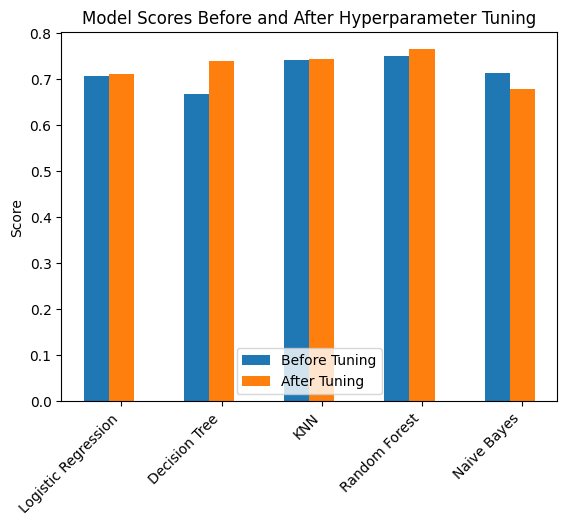

In [ ]:

model_names = list(model_scores.keys())
scores_before = list(model_scores.values())
scores_after = list(best_model_scores.values())

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots()

rects1 = ax.bar(x - width, scores_before, width, label='Before Tuning')
rects2 = ax.bar(x, scores_after, width, label='After Tuning')

ax.set_ylabel('Score')
ax.set_title('Model Scores Before and After Hyperparameter Tuning')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')

ax.legend()

plt.savefig('figures/scores_svd.png')  # Save the figure
plt.show()
